# [스프린트 미션 4] 딥러닝 기초 + PyTorch 문법



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.0


## Part 1. 기초

### 기초 1. 텐서 생성
0부터 11까지의 정수를 순서대로 담은 **(3, 4) 크기의 float32 텐서** `t1`을 만들어 주세요.

> 힌트: `torch.arange()`, `reshape()`(또는 `view()`), `dtype`

In [2]:
# 정답
t1 = torch.arange(12, dtype=torch.float32).reshape(3, 4)
print(t1)


tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])


### 기초 2. 인덱싱과 슬라이싱
텐서 `t2`에서 다음 세 가지를 추출하세요.
- `row2`: 세 번째 행 (인덱스 2)
- `col_last`: 마지막 열
- `sub`: 1~2행, 1~3열 부분 텐서 → shape `(2, 3)`

In [4]:
t2 = torch.arange(20).reshape(4, 5)
print(t2)

tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]])


In [5]:
# 정답
row2 = t2[2]
col_last = t2[:, -1]
sub = t2[1:3, 1:4]
print(row2, col_last, sub, sep="\n")


tensor([10, 11, 12, 13, 14])
tensor([ 4,  9, 14, 19])
tensor([[ 6,  7,  8],
        [11, 12, 13]])


### 기초 3. 모양 바꾸기 — squeeze, unsqueeze, reshape 
텐서 `t3`의 모양을 아래와 같이 바꿔 보세요.
- `a`: `t3`에서 크기가 1인 차원을 제거해 `(3, 4)`로
- `b`: `a`의 **맨 뒤에** 크기 1인 차원을 추가해 `(3, 4, 1)`로
- `c`: `t3`의 데이터를 `(2, 6)` 모양으로 재배열

In [7]:
t3 = torch.randn(3, 1, 4)
print(t3.shape)

torch.Size([3, 1, 4])


In [8]:
# 정답
a = t3.squeeze(1)
b = a.unsqueeze(-1)
c = t3.reshape(2, 6)
print(a.shape, b.shape, c.shape)


torch.Size([3, 4]) torch.Size([3, 4, 1]) torch.Size([2, 6])


### 기초 4. 타입 캐스팅 
- `t4_long`: `t4`를 정수(`long`) 타입으로 변환 (소수점 버림 → `[1, 2, 3]`)
- `t4_float`: `t4_long`을 다시 `float32`로 변환

In [10]:
t4 = torch.tensor([1.7, 2.3, 3.9])
print(t4, t4.dtype)

tensor([1.7000, 2.3000, 3.9000]) torch.float32


In [11]:
# 정답
t4_long = t4.long()
t4_float = t4_long.float()
print(t4_long, t4_long.dtype)
print(t4_float, t4_float.dtype)


tensor([1, 2, 3]) torch.int64
tensor([1., 2., 3.]) torch.float32


### 기초 5. 텐서 이어붙이기 — cat과 stack 
`a5`(2×3, 전부 1)와 `b5`(2×3, 전부 0)를 이어붙여 보세요.
- `cat0`: dim=0 방향으로 이어붙이기 → `(4, 3)`
- `cat1`: dim=1 방향으로 이어붙이기 → `(2, 6)`
- `stacked`: **새로운 차원**을 만들어 쌓기 → `(2, 2, 3)`

> `cat`은 기존 차원을 따라 이어붙이고, `stack`은 차원을 하나 새로 만든다는 차이를 확인해 보세요.

In [13]:
a5 = torch.ones(2, 3)
b5 = torch.zeros(2, 3)

In [14]:
# 정답
cat0 = torch.cat([a5, b5], dim=0)
cat1 = torch.cat([a5, b5], dim=1)
stacked = torch.stack([a5, b5], dim=0)
print(cat0.shape, cat1.shape, stacked.shape)


torch.Size([4, 3]) torch.Size([2, 6]) torch.Size([2, 2, 3])


### 기초 6. 행렬곱과 원소곱 
- `mm`: `m1`(2×3)과 `m2`(3×4)의 **행렬곱** → `(2, 4)`
- `ew`: `m1`과 `m3`(2×3)의 **원소별 곱** → `(2, 3)`

In [15]:
m1 = torch.tensor([[1., 2., 3.],
                   [4., 5., 6.]])
m2 = torch.ones(3, 4)
m3 = torch.full((2, 3), 2.)

In [16]:
# 정답
mm = m1 @ m2
ew = m1 * m3
print(mm, ew, sep="\n")


tensor([[ 6.,  6.,  6.,  6.],
        [15., 15., 15., 15.]])
tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.]])


### 기초 7. Autograd로 기울기 구하기 
함수 $y = x^2 + 3x$ 의 $x = 2$ 에서의 기울기를 autograd로 구하세요.

수학적으로 $\frac{dy}{dx} = 2x + 3$ 이므로, $x=2$에서의 기울기는 **7**입니다.
- `x`: 값이 2.0이고 `requires_grad=True`인 텐서
- `y`를 계산하고 역전파를 수행
- `grad`: `x`에 저장된 기울기

In [17]:
# 정답
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2 + 3 * x
y.backward()
grad = x.grad
print(grad)


tensor(7.)


### 기초 8. 활성화 함수 
딥러닝 기본기에서 배운 활성화 함수를 직접 적용해 보세요.
- `relu_out`: `z`에 **ReLU** 적용 (음수는 0으로)
- `sig_out`: `z`에 **Sigmoid** 적용 (0~1 사이 값으로)
- `probs`: `logits`에 **Softmax**를 적용해 확률 분포로 (합이 1)

In [18]:
z = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])
logits = torch.tensor([1.0, 2.0, 3.0])

In [19]:
# 정답
relu_out = F.relu(z)
sig_out = torch.sigmoid(z)
probs = F.softmax(logits, dim=0)
print(relu_out, sig_out, probs, sep="\n")


tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])
tensor([0.1192, 0.3775, 0.5000, 0.6225, 0.8808])
tensor([0.0900, 0.2447, 0.6652])


### 기초 9. 텐서를 device로 옮기기 
GPU가 있으면 GPU를, 없으면 CPU를 사용하도록 device를 설정하고 텐서를 옮겨 보세요.
- `device`: GPU 사용 가능 시 `"cuda"`, 아니면 `"cpu"`
- `t9_dev`: `t9`를 `device`로 옮긴 텐서

> 이렇게 작성해 두면 같은 코드가 GPU 유무와 관계없이 동작합니다. 모델과 데이터를 같은 device에 두는 습관은 미션 5부터 계속 쓰게 돼요.

In [20]:
t9 = torch.randn(2, 2)

In [21]:
# 정답
device = "cuda" if torch.cuda.is_available() else "cpu"
t9_dev = t9.to(device)
print(f"사용 중인 device: {device}")


사용 중인 device: cpu


## Part 2. 심화

### 심화 1. 손실 함수 — 직접 계산 vs 내장 함수 
- `mse_manual`: MSE 공식(오차 제곱의 평균) 그대로 직접 계산
- `mse_builtin`: `nn.MSELoss`를 사용해 계산 → 두 값이 같은지 확인
- `ce`: 분류 문제용 — `logits2`와 정수 라벨 `labels`로 `nn.CrossEntropyLoss` 계산

> ⚠️ `CrossEntropyLoss`는 내부에 Softmax가 포함되어 있어 모델 출력(logits)을 **그대로** 넣어야 하고, 라벨은 원-핫이 아닌 **정수(long)** 여야 합니다.

In [22]:
pred = torch.tensor([2.5, 0.0, 2.0])
target = torch.tensor([3.0, -0.5, 2.0])

logits2 = torch.tensor([[2.0, 0.5, 0.3],
                        [0.2, 2.5, 0.1]])
labels = torch.tensor([0, 1])

In [23]:
# 정답
mse_manual = ((pred - target) ** 2).mean()
mse_builtin = nn.MSELoss()(pred, target)
ce = nn.CrossEntropyLoss()(logits2, labels)
print(mse_manual, mse_builtin, ce, sep="\n")


tensor(0.1667)
tensor(0.1667)
tensor(0.2577)


### 심화 2. Autograd만으로 선형 회귀 학습하기 
`nn.Module` 없이 **순수 autograd**만으로 $y = 2x + 1$ 데이터를 학습해 보세요.

채워야 할 곳 (4곳):
1. 예측값 계산: $\hat{y} = xw + b$
2. 역전파 수행
3. 경사 하강법으로 `w`, `b` 갱신 (`w -= lr * w.grad` 형태)
4. `w`, `b`의 기울기를 0으로 초기화

> 파라미터 갱신은 `with torch.no_grad():` 안에서 해야 합니다. 갱신 자체가 연산 그래프에 기록되면 안 되기 때문이에요.

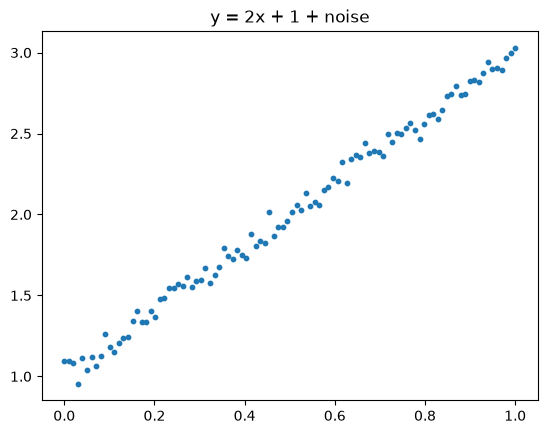

In [24]:
# y = 2x + 1 에 약간의 노이즈를 섞은 데이터
torch.manual_seed(42)
x2 = torch.linspace(0, 1, 100).unsqueeze(1)
y2 = 2 * x2 + 1 + 0.05 * torch.randn(100, 1)

plt.scatter(x2, y2, s=10)
plt.title("y = 2x + 1 + noise")
plt.show()

In [25]:
# 정답
lr = 0.3
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

losses2 = []
for step in range(500):
    y_hat = x2 * w + b
    loss = ((y_hat - y2) ** 2).mean()
    losses2.append(loss.item())
    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    w.grad.zero_()
    b.grad.zero_()

print(f"학습된 w: {w.item():.3f} (정답: 2)")
print(f"학습된 b: {b.item():.3f} (정답: 1)")
print(f"최종 손실: {losses2[-1]:.5f}")


학습된 w: 1.997 (정답: 2)
학습된 b: 1.004 (정답: 1)
최종 손실: 0.00241


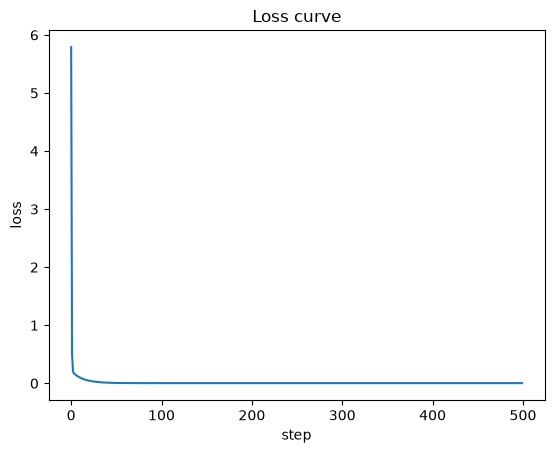

In [26]:
plt.plot(losses2)
plt.xlabel("step"); plt.ylabel("loss"); plt.title("Loss curve")
plt.show()

### 심화 3. nn.Module로 선형 회귀 구현하기 
심화 2와 같은 문제를 이번에는 **PyTorch 표준 방식**(`nn.Module` + `optimizer`)으로 풀어 보세요.

채워야 할 곳 (2곳):
1. `__init__`: 입력 1차원 → 출력 1차원의 선형 층 (`nn.Linear`)
2. `forward`: 입력을 선형 층에 통과시켜 반환

학습 코드는 완성된 상태로 제공됩니다. 학습 후 `model.linear.weight`와 `bias`가 정답(2와 1)에 가까워졌는지, 그리고 `nn.Linear`의 파라미터가 자동으로 등록되는 것을 확인해 보세요.

In [27]:
# 정답
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)


torch.manual_seed(42)
model3 = LinearRegression()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model3.parameters(), lr=0.3)

for epoch in range(500):
    optimizer.zero_grad()
    loss = criterion(model3(x2), y2)
    loss.backward()
    optimizer.step()

print(f"학습된 weight: {model3.linear.weight.item():.3f} (정답: 2)")
print(f"학습된 bias  : {model3.linear.bias.item():.3f} (정답: 1)")
for name, p in model3.named_parameters():
    print(name, p.shape, type(p).__name__)


학습된 weight: 1.997 (정답: 2)
학습된 bias  : 1.004 (정답: 1)
linear.weight torch.Size([1, 1]) Parameter
linear.bias torch.Size([1]) Parameter


### 심화 4. 2층 MLP 분류 모델 만들기 
초승달 모양의 2차원 데이터(`make_moons`)를 분류하는 **2층 MLP**를 만들어 보세요.

모델 구조 (딥러닝 기본기의 다층 퍼셉트론 그대로입니다):
- `fc1`: 입력 2차원 → 은닉 **16**차원 선형 층
- `fc2`: 은닉 16차원 → 출력 **2**차원(클래스 수) 선형 층
- `forward`: 입력 → `fc1` → **ReLU** → `fc2` → 반환

> ⚠️ 출력에 Softmax를 붙이지 마세요. 심화 1에서 확인했듯 `CrossEntropyLoss`가 내부에서 처리합니다.

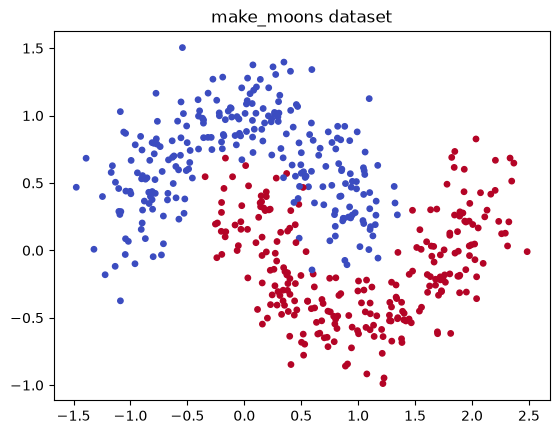

data source: local two-moons compatibility path
torch.Size([500, 2]) torch.Size([500])


In [28]:
try:
    from sklearn.datasets import make_moons
    moons_source = "sklearn.datasets.make_moons"
except ImportError:
    import numpy as np

    def make_moons(n_samples=500, noise=0.2, random_state=42):
        rng = np.random.RandomState(random_state)
        n_outer = n_samples // 2
        n_inner = n_samples - n_outer
        outer_theta = np.linspace(0, np.pi, n_outer)
        inner_theta = np.linspace(0, np.pi, n_inner)
        outer = np.c_[np.cos(outer_theta), np.sin(outer_theta)]
        inner = np.c_[1 - np.cos(inner_theta), 1 - np.sin(inner_theta) - 0.5]
        features = np.vstack([outer, inner])
        labels_np = np.hstack([np.zeros(n_outer), np.ones(n_inner)]).astype(np.intp)
        order = rng.permutation(n_samples)
        features, labels_np = features[order], labels_np[order]
        if noise is not None:
            features += rng.normal(scale=noise, size=features.shape)
        return features, labels_np

    moons_source = "local two-moons compatibility path"

X_np, y_np = make_moons(n_samples=500, noise=0.2, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=15)
plt.title("make_moons dataset")
plt.show()
print("data source:", moons_source)
print(X.shape, y.shape)


In [29]:
# 정답
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


model4 = MLP()
print(model4)


MLP(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)


### 심화 5. 학습 루프 완성하기 
심화 4에서 만든 MLP를 학습시키는 루프를 완성하세요. 학습 루프의 5단계를 순서대로 채우면 됩니다.

1. 기울기 초기화 (`optimizer.zero_grad()`)
2. 순전파 — 모델에 `X`를 넣어 logits 계산
3. 손실 계산 (`criterion` 사용)
4. 역전파 (`loss.backward()`)
5. 파라미터 갱신 (`optimizer.step()`)

In [30]:
# 정답
torch.manual_seed(42)
model5 = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model5.parameters(), lr=0.01)

losses5 = []
for epoch in range(300):
    optimizer.zero_grad()
    logits = model5(X)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    losses5.append(loss.item())

print(f"최종 손실: {losses5[-1]:.4f}")


최종 손실: 0.0670


학습 정확도: 0.980


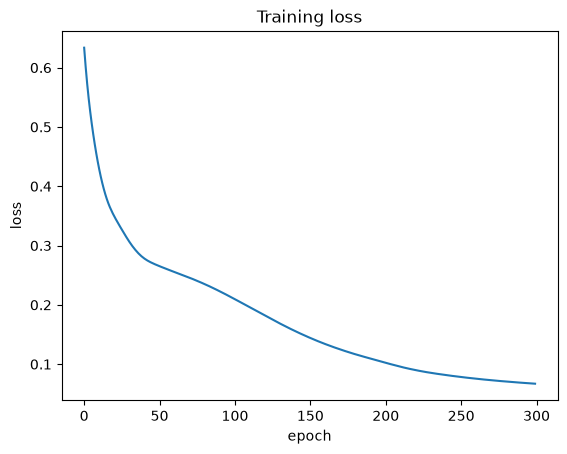

In [31]:
with torch.no_grad():
    acc = (model5(X).argmax(dim=1) == y).float().mean().item()
print(f"학습 정확도: {acc:.3f}")
assert acc > 0.85, "정확도가 너무 낮습니다. 학습 루프를 다시 확인해 보세요."

plt.plot(losses5)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Training loss")
plt.show()

### 심화 6. DataLoader로 미니배치 학습 
심화 5에서는 전체 데이터(500개)를 한 번에 넣었지만, 실전에서는 데이터를 **미니배치**로 나눠 학습합니다.

채워야 할 곳:
1. `TensorDataset`으로 `X`, `y`를 묶어 `dataset` 생성
2. `DataLoader`로 `batch_size=64`, `shuffle=True`인 `loader` 생성
3. 배치(`xb`)로 순전파하고 배치 라벨(`yb`)로 손실 계산

In [32]:
from torch.utils.data import TensorDataset, DataLoader

In [33]:
# 정답
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

torch.manual_seed(42)
model6 = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model6.parameters(), lr=0.01)

losses6 = []
for epoch in range(100):
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = model6(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    losses6.append(epoch_loss / len(dataset))

print(f"최종 손실: {losses6[-1]:.4f}")


최종 손실: 0.0586


### 심화 7. 옵티마이저와 학습률 실험 
같은 모델·데이터라도 **옵티마이저와 학습률**에 따라 학습이 크게 달라집니다. 아래 제공된 `train_with` 함수로 네 가지 설정을 학습시키고 손실 곡선을 비교해 보세요.

| 설정 | 옵티마이저 | 학습률 |
|---|---|---|
| ① | SGD | 0.01 |
| ② | SGD | 0.5 |
| ③ | SGD | 10.0 |
| ④ | Adam | 0.01 |

In [35]:
def train_with(optimizer_fn, epochs=200):
    """주어진 옵티마이저 설정으로 새 MLP를 학습시키고 손실 기록을 반환합니다."""
    torch.manual_seed(0)
    model = MLP()
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_fn(model.parameters())
    losses = []
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

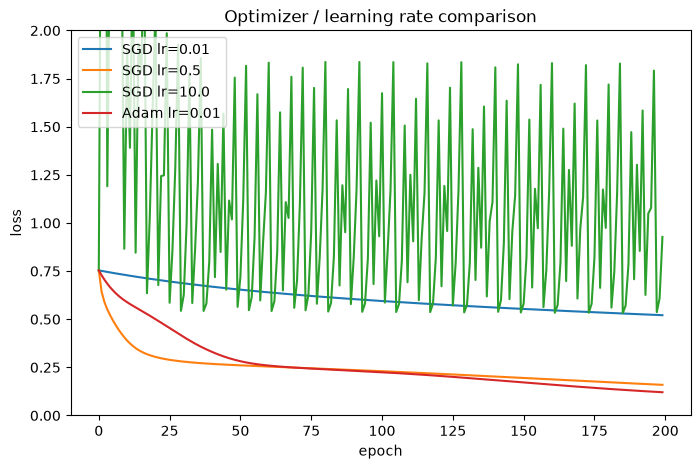

In [36]:
# 정답
results = {}
results["SGD lr=0.01"] = train_with(lambda p: torch.optim.SGD(p, lr=0.01))
results["SGD lr=0.5"] = train_with(lambda p: torch.optim.SGD(p, lr=0.5))
results["SGD lr=10.0"] = train_with(lambda p: torch.optim.SGD(p, lr=10.0))
results["Adam lr=0.01"] = train_with(lambda p: torch.optim.Adam(p, lr=0.01))

plt.figure(figsize=(8, 5))
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.ylim(0, 2)
plt.legend()
plt.title("Optimizer / learning rate comparison")
plt.show()


### 심화 7 — 서술 문제
위 손실 곡선을 보고 아래 질문에 답해 주세요. (다음 마크다운 셀에 작성)

1. 가장 빠르고 안정적으로 수렴한 설정은 무엇인가요?
2. `SGD lr=10.0`에서는 어떤 일이 일어났나요? 딥러닝 기본기에서 배운 내용을 바탕으로 **이유**를 설명해 주세요.
3. Adam이 SGD와 다른 점은 무엇인가요? (힌트: 모멘텀, RMSProp)

## 정답

1. **가장 빠르고 안정적으로 수렴한 설정:** 이번 실행에서는 `Adam lr=0.01`입니다. 그래프의 감소 속도와 마지막 loss를 함께 근거로 판단합니다.
2. **`SGD lr=10.0`:** 이번 실행에서는 loss가 비유한 값이 되지는 않았지만 큰 폭으로 오르내렸습니다. 학습률이 너무 커서 낮은 지점을 반복해서 지나치는 overshooting이 일어났기 때문입니다. 초기값이나 데이터가 달라지면 실제 관찰 결과도 달라질 수 있습니다.
3. **Adam과 SGD:** 기본 SGD는 현재 gradient에 하나의 학습률을 곱해 갱신합니다. Adam은 gradient의 1차·2차 모멘트를 추정해 파라미터별 갱신 크기를 조절합니다.
